# OCR-based Image Classification

This notebook extracts text from images using OCR (pytesseract) and trains a text classifier (TF-IDF + Logistic Regression) to predict the image class. It trains on all labeled images under `Data/` and evaluates on all labeled images under `VAL/`. Predictions below the confidence threshold are forced to `Indeterminado`.

In [20]:
# Imports and configuration
# from pathlib import Path
import importlib, subprocess, sys
import json
import os
import warnings
import re
import unicodedata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytesseract
import cv2
from pathlib import Path
from PIL import Image
from joblib import dump, load
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')
from nltk.stem.snowball import SnowballStemmer


In [21]:
# Install required Python packages if missing (Tesseract is system-level)
def ensure_package(pkg, import_name=None):
    module_name = import_name or pkg
    try:
        importlib.import_module(module_name)
        print(f'OK: {pkg} available')
    except ModuleNotFoundError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

ensure_package('pytesseract')
ensure_package('Pillow', 'PIL')
ensure_package('scikit-learn', 'sklearn')
ensure_package('joblib')
ensure_package('pandas')
ensure_package('tqdm')
ensure_package('numpy')
ensure_package('matplotlib')

OK: pytesseract available
OK: Pillow available
OK: scikit-learn available
OK: joblib available
OK: pandas available
OK: tqdm available
OK: numpy available
OK: matplotlib available


In [22]:
print(sys.executable)
!{sys.executable} -m pip show opencv-python

c:\Users\ibf\Desktop\TFM\Nou_projecte\.venv\Scripts\python.exe
Name: opencv-python
Version: 4.13.0.92
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: c:\Users\ibf\Desktop\TFM\Nou_projecte\.venv\Lib\site-packages
Requires: numpy
Required-by: 


In [23]:
def preprocess(img):
    img = np.array(img)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    # Increase contrast
    gray = cv2.convertScaleAbs(gray, alpha=1.5, beta=10)
    # Resize (important for OCR)
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    # Denoise
    gray = cv2.medianBlur(gray, 3)
    # Adaptive threshold works better than Otsu for uneven lighting
    thresh = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31, 2
    )

    return Image.fromarray(thresh)


ROOT = Path('..').resolve().parent
DATA_DIR = ROOT / 'Data'
VAL_DIR = ROOT / 'VAL'
MODELS_DIR = ROOT / 'TFM' / 'Models'
MODELS_DIR.mkdir(exist_ok=True)
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
CONFIDENCE_THRESHOLD = 0.80

def configure_tesseract():
    candidates = [
        r'C:\Users\ibf\AppData\Local\Programs\Tesseract-OCR\tesseract.exe',
        os.path.join(os.environ.get('LOCALAPPDATA', ''), 'Programs', 'Tesseract-OCR', 'tesseract.exe'),
    ]
    for candidate in candidates:
        if candidate and os.path.exists(candidate):
            pytesseract.pytesseract.tesseract_cmd = candidate
            break
    print('pytesseract version:', pytesseract.get_tesseract_version())

configure_tesseract()

pytesseract version: 5.5.0.20241111


## Strat 1 Filtering (No BERT)

In [24]:

stemmer = SnowballStemmer("spanish")

def stem_token(token):
    return stemmer.stem(token)


SPANISH_STOPWORDS = {
    # TODO Add more stopwords
    'Jordi', 'de', 'la', 'el', 'y', 'a', 'que', 'los', 'del', 'se', 'las', 'por', 'un',
    'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 'sus', 'le', 'ya', 'o',
    'este', 'entre', 'cuando', 'muy', 'sobre', 'caixa', 'caixabank', 'buenos', 'dias', 'rentabilidad', 
    'mis', 'cuenta', 'cuentas', 'bizum', 'enviar bizum', 'resumen', 'mensual', 'mis', 'recibo', 'recibos',
    'tarjeta', 'tarjetas', 'mostrar', 'todo', 'inicio', 'disfruta', 'operar', 'contratar', 'imaginbank', 
    'innmaginbank', 'trasnferencia', 'recibo', 'recibos', 'contatar', 'productos', 'mecardos', 'buscar',
    'favoritos', 'perfil', 'plusvalia', 'rentabilidad', 'posiciones', 'ordenes', 'visa', 'debit', 'certificado',
    'titularidad', 'solicitar', 'devolucion', 'buscar', 'movimientos', 'opciones', 'gastos', 'ingresos', 'todo',
    'historial', 'buenas', 'noches', 'Albert'
}

VOWELS = set("aeiou")



def normalize_text(text):
    # Convert to lowercase
    text = text.lower()

    # Normalize accents (é -> e, ñ -> n, etc.)
    text = unicodedata.normalize("NFKD", text)
    text = "".join(
        c for c in text
        if not unicodedata.combining(c)
    )

    # Remove special characters (keep letters, numbers, and spaces)
    text = re.sub(r"[^a-z0-9\s]", "", text)

    return text


def remove_numbers_and_symbols(text):
    # Remove digits and specified symbols
    text = re.sub(r"[0-9\.,\*\+\-/\\\[\]\(\)]", "", text)
    return text


def looks_like_repeated_noise(token):
    return len(token) > 4 and len(set(token)) <= 2


def vowel_ratio(token):
    vowels = sum(c in VOWELS for c in token)
    return vowels / len(token)


def looks_like_ocr_noise(token):
    if len(token) < 3:
        return True

    if looks_like_repeated_noise(token):
        return True

    # Spanish words usually contain at least some vowels
    if vowel_ratio(token) < 0.15:
        return True

    return False

def has_repeated_letters(token):
    for i in range(len(token) - 2):
        if token[i] == token[i + 1] == token[i + 2]:
            return True
    return False

def remove_duplicate_tokens(tokens):
    seen = set()
    unique_tokens = []

    for token in tokens:
        if token not in seen:
            seen.add(token)
            unique_tokens.append(token)

    return unique_tokens

def has_weird_consonant_cluster(token):
    return bool(re.search(r"[bcdfghjklmnpqrstvwxyz]{5,}", token))

def normalize_repetitions(token):
    # coooool -> cool
    return re.sub(r"(.)\1{2,}", r"\1\1", token)


def clean_ocr_text(text, stopwords = SPANISH_STOPWORDS, min_token_length=3, min_tokens=3):
    if not text:
        return ""

    text = remove_numbers_and_symbols(text)
    text = normalize_text(text)
    # Keep only letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)

    raw_tokens = text.split()
    cleaned_tokens = []

    for token in raw_tokens:
        token = normalize_repetitions(token)
        token = stem_token(token)
        # if len(token) < min_token_length:
        #     continue
        # Paraula que no aporta valor
        if token in stopwords:
            continue
        # Soroll
        if looks_like_ocr_noise(token):
            continue
        # Paraules amb lletres repetides
        if has_repeated_letters(token):
            continue
        # Paraules amb clusters de consonants estranys
        if has_weird_consonant_cluster(token):
            continue    

        #  TODO ADD MORE STRATS
        cleaned_tokens.append(token)

    # unique_tokens = remove_duplicate_tokens(cleaned_tokens)

    # Reject almost-empty OCR
    if len(cleaned_tokens) < min_tokens:
        return ""
    
    return " ".join(cleaned_tokens)

## Strat 2 (BERT)

In [25]:
def clean_for_bert(text):
    if not text:
        return ""

    text = text.lower()
    text = remove_numbers_and_symbols(text)
    # Keep accents (important!)
    # Keep punctuation (BERT understands it)

    # Fix spacing only
    text = re.sub(r"\s+", " ", text).strip()
    
    raw_tokens = text.split()
    cleaned_tokens = []

    for token in raw_tokens:
        token = normalize_repetitions(token)
        # if len(token) < min_token_length:
        #     continue
        # Paraula que no aporta valor
        # if token in stopwords:
        #     continue
        # Soroll
        if looks_like_ocr_noise(token):
            continue
        # Paraules amb lletres repetides
        if has_repeated_letters(token):
            continue
        # Paraules amb clusters de consonants estranys
        if has_weird_consonant_cluster(token):
            continue    

        #  TODO ADD MORE STRATS
        cleaned_tokens.append(token)

    return " ".join(cleaned_tokens)


## OCR and Extraction executin

In [26]:
# Data loading and OCR extraction
def collect_samples(root_dir):
    root = Path(root_dir)
    classes = sorted([path.name for path in root.iterdir() if path.is_dir()])
    samples = []
    for class_name in classes:
        for image_path in (root / class_name).rglob('*'):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                samples.append((str(image_path), class_name))
    return classes, samples

def extract_text_from_image(path, crop_top=120, crop_bottom=120):
    try:
        img = Image.open(path).convert('RGB')

        width, height = img.size
        if height > (crop_top + crop_bottom):
            top = int(crop_top)
            bottom = int(height - crop_bottom)
            if top < bottom:
                img = img.crop((0, top, width, bottom))

        # Opcional: aplicar tu preprocesado
        img = preprocess(img)

        # custom_config = r'--oem 3 --psm 6'
        custom_config = r'--oem 3 --psm 4 -c preserve_interword_spaces=1'

        return pytesseract.image_to_string(
            img,
            lang='spa',
            config=custom_config
        ).strip()

    except Exception as exc:
        print(f'OCR failed for {path}: {exc}')
        return ''

def build_ocr_dataframe(root_dir, split_name):
    classes, samples = collect_samples(root_dir)
    records = []

    for image_path, label in tqdm(samples, desc=f'OCR {split_name}'):
        raw_text = extract_text_from_image(image_path)
        # Choose one
        # clean_text = clean_ocr_text(raw_text)
        clean_text_for_bert = clean_for_bert(raw_text)

        records.append(
            {
                'path': image_path,
                'label': label,
                'raw_text': raw_text,
                'text': clean_text_for_bert,   # ✅ use cleaned text
            }
        )

    df = pd.DataFrame(records)

    print(f'{split_name} samples:', len(df))
    print(f'{split_name} empty OCR texts:',
          int((df['text'].fillna('').str.strip() == '').sum()))

    return classes, df

train_classes, train_df = build_ocr_dataframe(DATA_DIR, 'train')
val_classes, val_df = build_ocr_dataframe(VAL_DIR, 'val')
class_names = sorted(set(train_classes) | set(val_classes))
if 'Indeterminado' not in class_names:
    class_names.append('Indeterminado')
print('Class names:', class_names)

OCR train: 100%|██████████| 4405/4405 [1:49:49<00:00,  1.50s/it]  


train samples: 4405
train empty OCR texts: 570


OCR val: 100%|██████████| 718/718 [22:31<00:00,  1.88s/it] 

val samples: 718
val empty OCR texts: 19
Class names: ['Banner aplicación', 'Cierre aplicación', 'Error aplicativo', 'Error funcional', 'Error terminal', 'Indeterminado', 'Revisión circuito', 'Timeout']


In [27]:
# sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2

from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
)

def compute_embeddings(texts, model, batch_size=32):
    embeddings = model.encode(
        texts.tolist(),
        batch_size=batch_size,
        show_progress_bar=True
    )
    return np.array(embeddings)

X_train = compute_embeddings(train_df['text'], embedding_model)
X_val = compute_embeddings(val_df['text'], embedding_model)

y_train = train_df['label']
y_val = val_df['label']

from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)



Batches: 100%|██████████| 23/23 [00:11<00:00,  1.92it/s]


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

evaluate

In [42]:
from sklearn.metrics import classification_report

OCR_THR = 0.750

def predict_with_threshold(probas, classes, threshold):
    predictions = []

    for prob in probas:
        max_idx = np.argmax(prob)
        max_prob = prob[max_idx]
        predicted_class = classes[max_idx]

        if max_prob < threshold:
            predictions.append("Indeterminado")
        else:
            predictions.append(predicted_class)

    return predictions

# y_pred = clf.predict(X_val)

y_proba = clf.predict_proba(X_val)
classes = clf.classes_

y_pred = predict_with_threshold(y_proba, classes, threshold=OCR_THR)
extended_classes = sorted(list(set(class_names) | {"empty"}))
# print(classification_report(y_val, y_pred))
print(classification_report(y_val, y_pred, labels=extended_classes))

                   precision    recall  f1-score   support

Banner aplicación       0.00      0.00      0.00        19
Cierre aplicación       1.00      0.54      0.70        41
 Error aplicativo       1.00      0.61      0.76        36
  Error funcional       0.00      0.00      0.00         2
   Error terminal       1.00      0.00      0.01       209
    Indeterminado       0.01      1.00      0.02         4
Revisión circuito       0.99      0.60      0.75       384
          Timeout       1.00      0.26      0.41        23
            empty       0.00      0.00      0.00         0

         accuracy                           0.40       718
        macro avg       0.56      0.33      0.29       718
     weighted avg       0.96      0.40      0.49       718



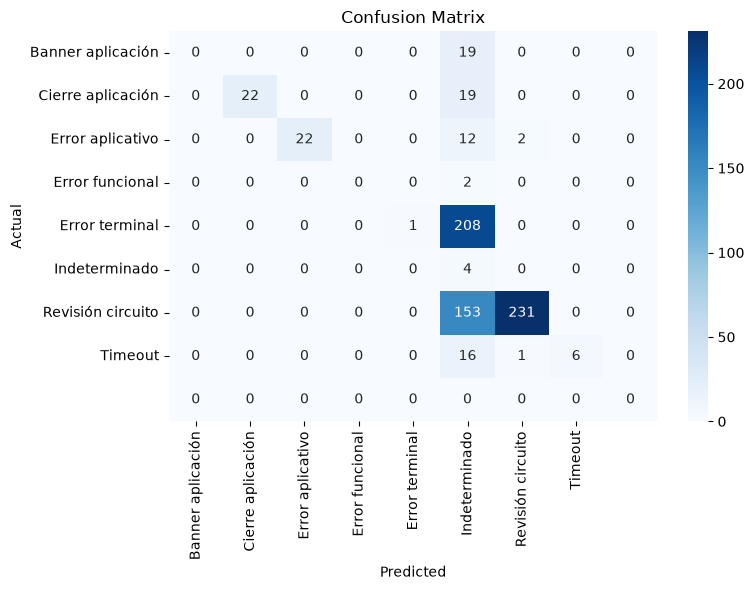

In [43]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
# cm = confusion_matrix(y_val, y_pred, labels=class_names)
cm = confusion_matrix(y_val, y_pred, labels=extended_classes)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()

plt.show()


Logistic Regression

In [29]:
# Train the OCR classifier on all Data images
if train_df['text'].fillna('').str.strip().eq('').all():
    raise RuntimeError('OCR returned empty text for every training image. Tesseract is required for this notebook.')

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df['text'].fillna(''))
y_train = train_df['label']

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, y_train)
print('Training complete.')
print('Train samples:', len(train_df))
print('Validation samples:', len(val_df))

Training complete.
Train samples: 4405
Validation samples: 718


Evaluating on VAL with confidence threshold: 0.8
Scores:
{
  "accuracy": 0.34958217270194986,
  "balanced_accuracy": 0.3446281560106986,
  "macro_f1": 0.30118078384613267,
  "weighted_f1": 0.4531902692751482,
  "uncertain_rate": 0.6518105849582173
}

Classification report:
                   precision    recall  f1-score   support

Banner aplicación       0.00      0.00      0.00        19
Cierre aplicación       1.00      0.54      0.70        41
 Error aplicativo       1.00      0.47      0.64        36
  Error funcional       0.00      0.00      0.00         2
   Error terminal       1.00      0.00      0.01       209
    Indeterminado       0.01      1.00      0.02         4
Revisión circuito       0.99      0.53      0.69       384
          Timeout       1.00      0.22      0.36        23

         accuracy                           0.35       718
        macro avg       0.62      0.34      0.30       718
     weighted avg       0.96      0.35      0.45       718



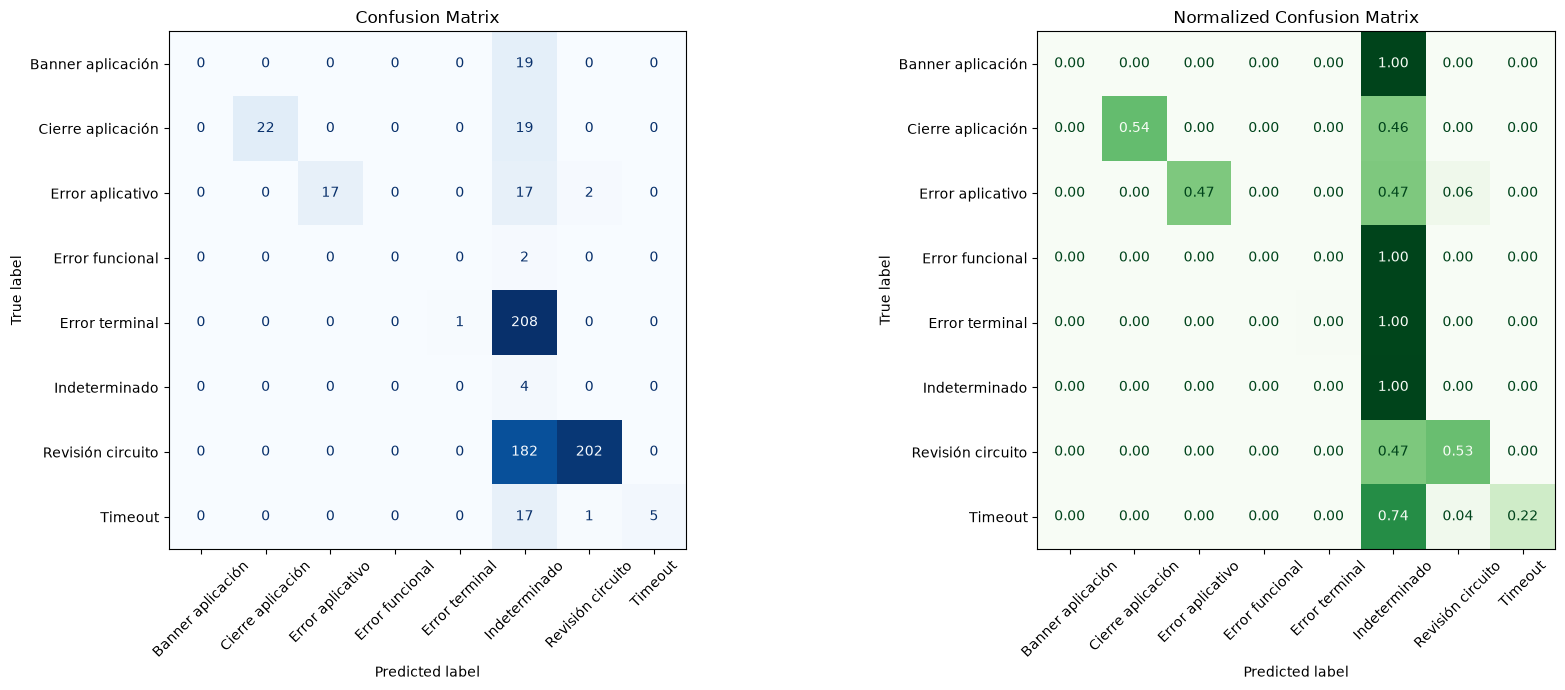

Validation rows: 718


In [30]:
# Evaluate on VAL with the {CONFIDENCE_THRESHOLD} confidence rule
print('Evaluating on VAL with confidence threshold:', CONFIDENCE_THRESHOLD)
X_val = vectorizer.transform(val_df['text'].fillna(''))
val_probabilities = clf.predict_proba(X_val)
raw_indices = val_probabilities.argmax(axis=1)
raw_labels = clf.classes_[raw_indices]
confidence = val_probabilities.max(axis=1)
final_labels = np.where(confidence >= CONFIDENCE_THRESHOLD, raw_labels, 'Indeterminado')

eval_df = val_df.copy().reset_index(drop=True)
eval_df['raw_prediction'] = raw_labels
eval_df['confidence'] = confidence
eval_df['prediction'] = final_labels
eval_df['is_indeterminate'] = eval_df['prediction'].eq('Indeterminado')

scores = {
    'accuracy': float(accuracy_score(eval_df['label'], eval_df['prediction'])),
    'balanced_accuracy': float(balanced_accuracy_score(eval_df['label'], eval_df['prediction'])),
    'macro_f1': float(f1_score(eval_df['label'], eval_df['prediction'], average='macro', zero_division=0)),
    'weighted_f1': float(f1_score(eval_df['label'], eval_df['prediction'], average='weighted', zero_division=0)),
    'uncertain_rate': float(eval_df['is_indeterminate'].mean()),
}

print('Scores:')
print(json.dumps(scores, indent=2))
print('\nClassification report:')
print(classification_report(eval_df['label'], eval_df['prediction'], labels=class_names, zero_division=0))

cm = confusion_matrix(eval_df['label'], eval_df['prediction'], labels=class_names)
cm_norm = confusion_matrix(eval_df['label'], eval_df['prediction'], labels=class_names, normalize='true')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[0], cmap='Blues', colorbar=False, xticks_rotation=45)
axes[0].set_title('Confusion Matrix')
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(ax=axes[1], cmap='Greens', colorbar=False, xticks_rotation=45, values_format='.2f')
axes[1].set_title('Normalized Confusion Matrix')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ocr_confusion_matrix_2.png', dpi=200, bbox_inches='tight')
plt.show()

print('Validation rows:', len(eval_df))

In [31]:
# Save model artifacts and validation outputs
dump(vectorizer, MODELS_DIR / 'ocr_vectorizer_2.joblib')
dump(clf, MODELS_DIR / 'ocr_text_classifier_2.joblib')
train_df.to_csv(MODELS_DIR / 'ocr_samples_train_2.csv', index=False)
val_df.to_csv(MODELS_DIR / 'ocr_samples_val_2.csv', index=False)
eval_df.to_csv(MODELS_DIR / 'ocr_validation_predictions_threshold_0p8_v2.csv', index=False)
with open(MODELS_DIR / 'ocr_validation_scores.json', 'w', encoding='utf-8') as f:
    json.dump(scores, f, indent=2, ensure_ascii=False)
print('Saved model artifacts to', MODELS_DIR.resolve())

Saved model artifacts to C:\Users\ibf\Desktop\TFM\Nou_projecte\TFM\Models


In [32]:
# Inference helper with the same confidence rule
def predict_image_class_from_ocr(image_path, confidence_threshold=CONFIDENCE_THRESHOLD, vectorizer_path=MODELS_DIR / 'ocr_vectorizer_2.joblib', clf_path=MODELS_DIR / 'ocr_text_classifier_2.joblib'):
    vec = load(vectorizer_path)
    model = load(clf_path)
    text = extract_text_from_image(image_path)
    if not text:
        return {'predicted': 'Indeterminado', 'raw_prediction': 'Indeterminado', 'confidence': 0.0, 'text': ''}
    features = vec.transform([text])
    probabilities = model.predict_proba(features)[0]
    index = int(probabilities.argmax())
    raw_label = model.classes_[index]
    confidence = float(probabilities[index])
    predicted = raw_label if confidence >= confidence_threshold else 'Indeterminado'
    return {'predicted': predicted, 'raw_prediction': raw_label, 'confidence': confidence, 'text': text}

example_path = val_df.iloc[0]['path'] if len(val_df) else train_df.iloc[0]['path']
print('Example path:', example_path)
print(predict_image_class_from_ocr(example_path))

Example path: C:\Users\ibf\Desktop\TFM\Nou_projecte\VAL\Banner aplicación\20260528131637_100097.png
{'predicted': 'Indeterminado', 'raw_prediction': 'Banner aplicación', 'confidence': 0.29237616999259675, 'text': '¿Nos permites acceder a tu geolocalización?\n\nEl permiso de ubicación solo lo utilizamos si autorizas\na la aplicación, y nos permite acceder a los datos de\ngeolocalización para:\n\nUn tratamiento comercial (si además tenemos tu\nconsentimiento)\n\n¡y Finalidades de lucha contra el fraude\n\nOfrecerte determinados servicios de la aplicación, como\nmostrarte la ubicación de la oficina más cercana\n\nLos datos de geolocalización se recogen únicamente si la\ngeolocalización está activada en el dispositivo, y se puede\nconfigurar en todo momento desde tu teléfono accediendo a\nAjustes>Geolocalización.\n\nCon carácter general, utilizaremos los datos de geolocalización\nen primer plano; por esta razón, te informaremos previamente\n\nen aquellos casos en que puedan utilizarse en s

## Notes

- The notebook uses all images under `Data/` for training and all images under `VAL/` for validation.
- Any prediction below the 0.80 confidence threshold is mapped to `Indeterminado`.
- The validation confusion matrix and score summary are saved in `Models/`.